In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

mu = np.log(3) / 2
sigma2 = 1/3 - (np.log(3)**2) / 4
sigma = np.sqrt(sigma2)

n_list = [10, 100, 1000, 10000]
B = 1000

def gen_x(size):
    y = np.random.uniform(1, 3, size)
    return 1 / y

--- ЧАСТИНА 1 ---


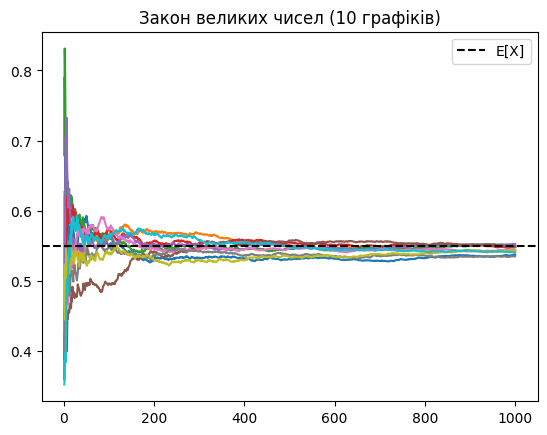

n=10 | середнє=0.5473, дисперсія=0.003279, P=0.988


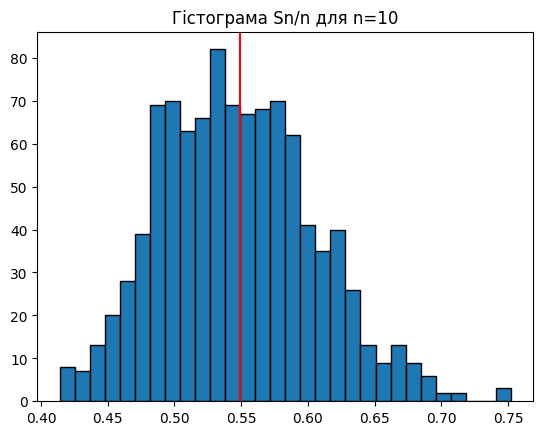

n=100 | середнє=0.5506, дисперсія=0.000307, P=0.96


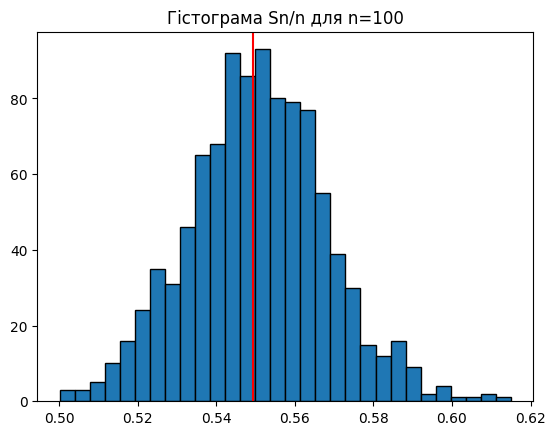

n=1000 | середнє=0.5493, дисперсія=0.000033, P=0.858


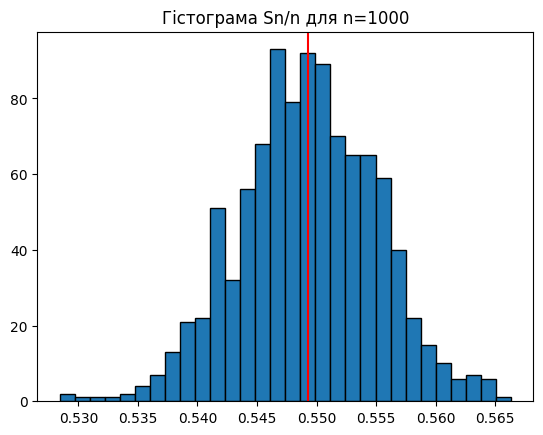

n=10000 | середнє=0.5493, дисперсія=0.000003, P=0.605


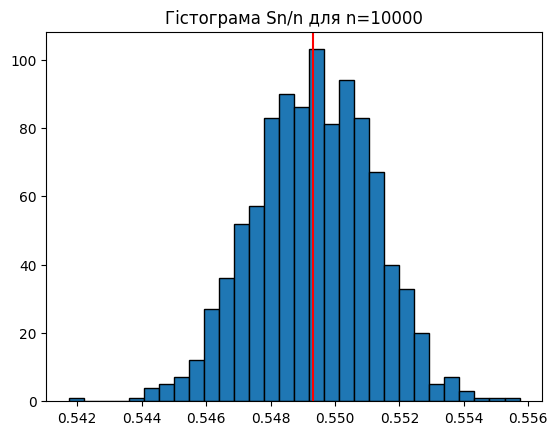

In [10]:
print("--- ЧАСТИНА 1 ---")

plt.figure()
for i in range(10):
    x = gen_x(1000)
    sn = np.cumsum(x)
    n_arr = np.arange(1, 1001)
    plt.plot(n_arr, sn / n_arr)

plt.axhline(y=mu, color='black', linestyle='--', label='E[X]')
plt.title("Закон великих чисел (10 графіків)")
plt.legend()
plt.show()

eps = 0.001

for n in n_list:
    mat = gen_x((B, n))
    sn_n = np.sum(mat, axis=1) / n

    mean_val = np.mean(sn_n)
    var_val = np.var(sn_n)
    prob = np.mean(np.abs(sn_n - mu) >= eps)

    print(f"n={n} | середнє={mean_val:.4f}, дисперсія={var_val:.6f}, P={prob}")

    plt.figure()
    plt.hist(sn_n, bins=30, edgecolor='black')
    plt.axvline(mu, color='red')
    plt.title(f"Гістограма Sn/n для n={n}")
    plt.show()

--- ЧАСТИНА 2 ---
n=10 | E[S=]=-0.0049, Var[S=]=0.0312


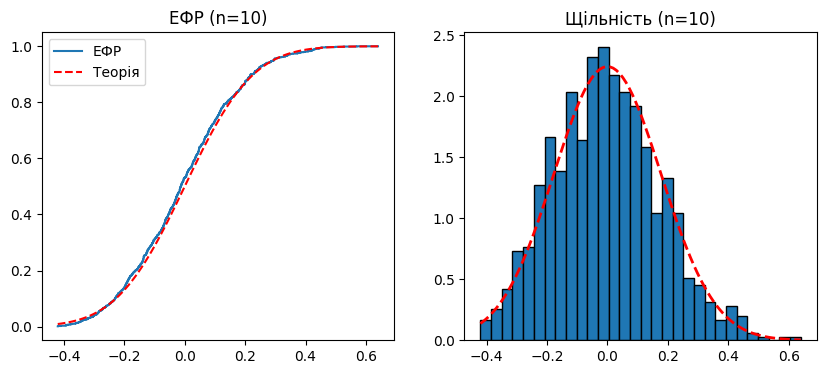

n=100 | E[S=]=-0.0031, Var[S=]=0.0330


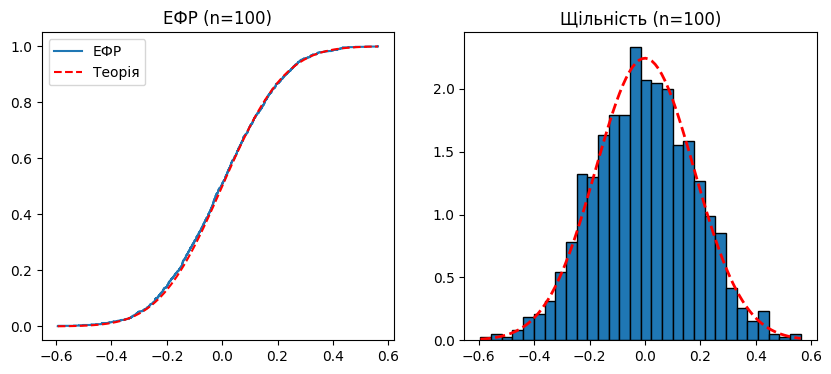

n=1000 | E[S=]=-0.0022, Var[S=]=0.0320


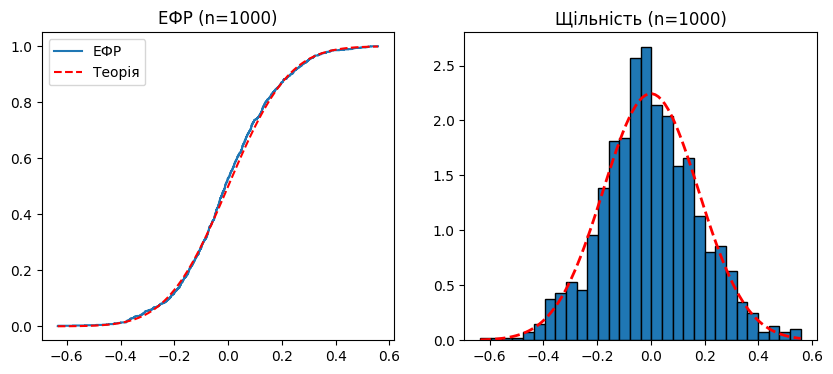

n=10000 | E[S=]=0.0046, Var[S=]=0.0299


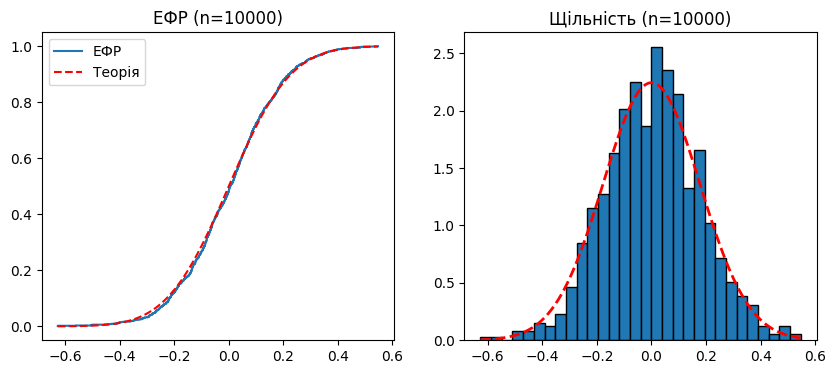

In [11]:
print("--- ЧАСТИНА 2 ---")

for n in n_list:
    mat = gen_x((B, n))
    sn = np.sum(mat, axis=1)

    s_tilde = (sn - n * mu) / np.sqrt(n)

    print(f"n={n} | E[S=]={np.mean(s_tilde):.4f}, Var[S=]={np.var(s_tilde):.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    x_sort = np.sort(s_tilde)
    y_ecdf = np.arange(1, B + 1) / B
    ax[0].step(x_sort, y_ecdf, label='ЕФР')

    x_teor = np.linspace(min(x_sort), max(x_sort), 100)
    ax[0].plot(x_teor, st.norm.cdf(x_teor, 0, sigma), 'r--', label='Теорія')
    ax[0].set_title(f"ЕФР (n={n})")
    ax[0].legend()

    ax[1].hist(s_tilde, bins=30, density=True, edgecolor='black')
    ax[1].plot(x_teor, st.norm.pdf(x_teor, 0, sigma), 'r--', lw=2)
    ax[1].set_title(f"Щільність (n={n})")

    plt.show()

--- ЧАСТИНА 3 ---
Точне значення: 8.6667

n=10: через X_j -> 11.0555 | через U[1,3] -> 7.5062
n=100: через X_j -> 8.8328 | через U[1,3] -> 8.8373
n=1000: через X_j -> 8.6875 | через U[1,3] -> 8.7514
n=10000: через X_j -> 8.6599 | через U[1,3] -> 8.7013


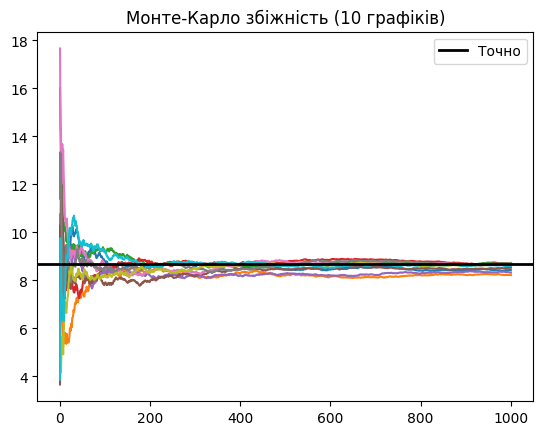

In [12]:
print("--- ЧАСТИНА 3 ---")
exact = 26 / 3
print(f"Точне значення: {exact:.4f}\n")

for n in n_list:
    x_samp = gen_x(n)
    int1 = np.mean(2 / x_samp**2)

    u_samp = np.random.uniform(1, 3, n)
    int2 = np.mean(u_samp**2 * 2)

    print(f"n={n}: через X_j -> {int1:.4f} | через U[1,3] -> {int2:.4f}")

plt.figure()
for i in range(10):
    u = np.random.uniform(1, 3, 1000)
    res = np.cumsum(u**2 * 2) / np.arange(1, 1001)
    plt.plot(np.arange(1, 1001), res)

plt.axhline(y=exact, color='black', lw=2, label='Точно')
plt.title("Монте-Карло збіжність (10 графіків)")
plt.legend()
plt.show()